In [75]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import make_circles
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

class DropoutLayer(nn.Module):
    def __init__(self, p=0.5):
        super().__init__()
        self.p = p

    def forward(self, x):
        if not self.training or self.p == 0.0:
            return x
        
        # Create a binary mask: 1 with probability (1-p), 0 with probability p
        mask = (torch.rand_like(x) > self.p).float()
        
        # Inverted dropout: scale up by 1/(1-p) to keep expected values the same
        return x * mask / (1 - self.p)


# 1. Load and split data
X, y = make_circles(n_samples=2000, noise=0.33, factor=0.5, random_state=42)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.4, random_state=42
)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

X_train = torch.FloatTensor(X_train)
X_test = torch.FloatTensor(X_test)
y_train = torch.LongTensor(y_train)
y_test = torch.LongTensor(y_test)

# Dictionary to store history for plotting
histories = {}

# Configurations to loop through
dropout_rates = [0.0, 0.1, 0.3, 0.5]

for dropout_rate in dropout_rates:
    print(f"\n--- Training Model with droupout rate {dropout_rate} ---")

    torch.manual_seed(42)
    
    # 2. Re-initialize the model for each run to reset weights
    model = nn.Sequential(
        nn.Linear(2, 500),
        nn.ReLU(),
        nn.DropoutLayer(p=dropout_rate),
        nn.Linear(500, 500),
        nn.ReLU(),
        nn.DropoutLayer(p=dropout_rate),
        nn.Linear(500, 2)
    )

    criterion = nn.CrossEntropyLoss()
    optimizer = optim.SGD(model.parameters(), lr=0.02)

    epoch_ticks = []
    train_accuracies = []
    test_accuracies = []

    # 4. Training Loop
    epochs = 2000
    for epoch in range(epochs):
        model.train()
        outputs = model(X_train)
        loss = criterion(outputs, y_train)
        
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        # Track metrics every 25 epochs
        if (epoch + 1) % 25 == 0:
            model.eval()
            with torch.no_grad():
                _, train_predicted = torch.max(outputs, 1)
                train_acc = (train_predicted == y_train).sum().item() / y_train.size(0)
                
                test_outputs = model(X_test)
                _, test_predicted = torch.max(test_outputs, 1)
                test_acc = (test_predicted == y_test).sum().item() / y_test.size(0)
            
            epoch_ticks.append(epoch + 1)
            train_accuracies.append(train_acc)
            test_accuracies.append(test_acc)
            
            if (epoch + 1) % 500 == 0:  # Reduced print frequency for cleaner console output
                print(f"Epoch [{epoch+1}/{epochs}] | Loss: {loss.item():.4f} | Train Acc: {train_acc*100:.1f}% | Test Acc: {test_acc*100:.1f}%")

    # Store histories for the plotting step
    histories[dropout_rate] = {
        'ticks': epoch_ticks,
        'train': train_accuracies,
        'test': test_accuracies
    }



--- Training Model with droupout rate 0.0 ---
Epoch [500/2000] | Loss: 0.4600 | Train Acc: 78.2% | Test Acc: 76.2%
Epoch [1000/2000] | Loss: 0.4575 | Train Acc: 78.1% | Test Acc: 76.2%
Epoch [1500/2000] | Loss: 0.4560 | Train Acc: 78.0% | Test Acc: 75.9%
Epoch [2000/2000] | Loss: 0.4549 | Train Acc: 78.0% | Test Acc: 75.6%

--- Training Model with droupout rate 0.1 ---
Epoch [500/2000] | Loss: 0.4690 | Train Acc: 77.6% | Test Acc: 75.6%
Epoch [1000/2000] | Loss: 0.4623 | Train Acc: 77.8% | Test Acc: 75.6%
Epoch [1500/2000] | Loss: 0.4654 | Train Acc: 77.4% | Test Acc: 75.4%
Epoch [2000/2000] | Loss: 0.4612 | Train Acc: 77.7% | Test Acc: 74.9%

--- Training Model with droupout rate 0.3 ---
Epoch [500/2000] | Loss: 0.4817 | Train Acc: 76.7% | Test Acc: 75.9%
Epoch [1000/2000] | Loss: 0.4796 | Train Acc: 76.5% | Test Acc: 75.9%
Epoch [1500/2000] | Loss: 0.4745 | Train Acc: 76.9% | Test Acc: 75.4%
Epoch [2000/2000] | Loss: 0.4676 | Train Acc: 77.9% | Test Acc: 75.1%

--- Training Model wi

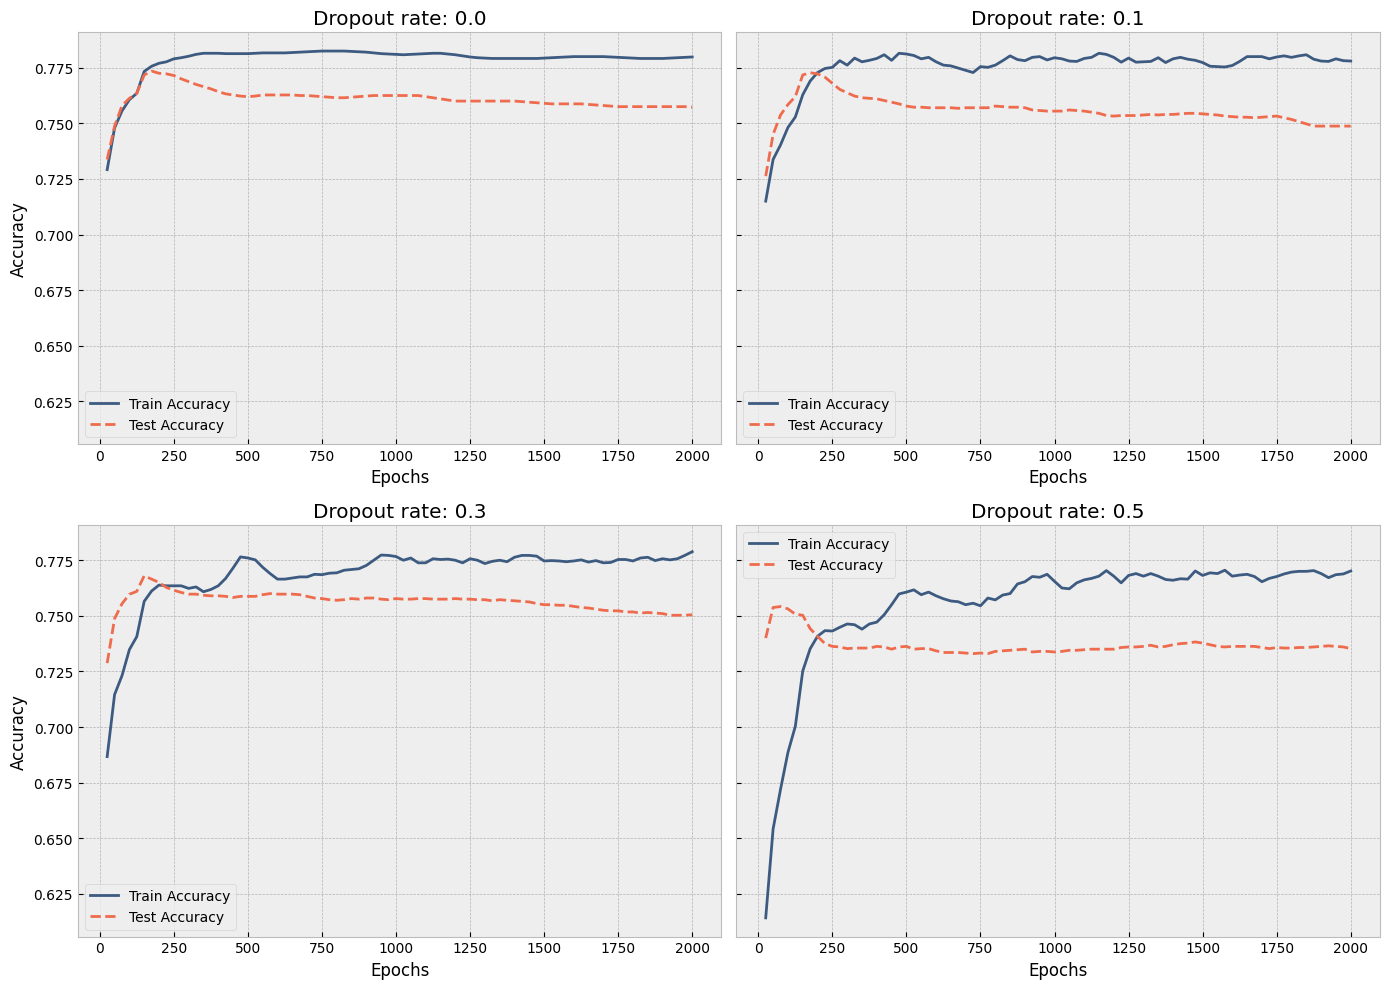

In [76]:
plt.style.use('bmh')
colors = ["#3d5a80", "#ee6c4d"]
window_size = 5

fig, axes = plt.subplots(2, 2, figsize=(14, 10), sharey=True)
axes = axes.flatten()  # makes indexing easy: axes[0..3]

for idx, dropout_rate in enumerate(dropout_rates):
    ax = axes[idx]
    hist = histories[dropout_rate]

    smooth_train = pd.Series(hist['train']).rolling(window=window_size, min_periods=1).mean()
    smooth_test  = pd.Series(hist['test']).rolling(window=window_size, min_periods=1).mean()

    ax.plot(hist['ticks'], smooth_train, label='Train Accuracy', color=colors[0], linewidth=2)
    ax.plot(hist['ticks'], smooth_test,  label='Test Accuracy',  color=colors[1], linewidth=2, linestyle='--')

    ax.set_title(f'Dropout rate: {dropout_rate}')
    ax.set_xlabel('Epochs')
    if idx % 2 == 0:          # left column only
        ax.set_ylabel('Accuracy')
    ax.legend()
    ax.grid(True)

plt.tight_layout()
plt.savefig('dropout_training.png')
plt.show()

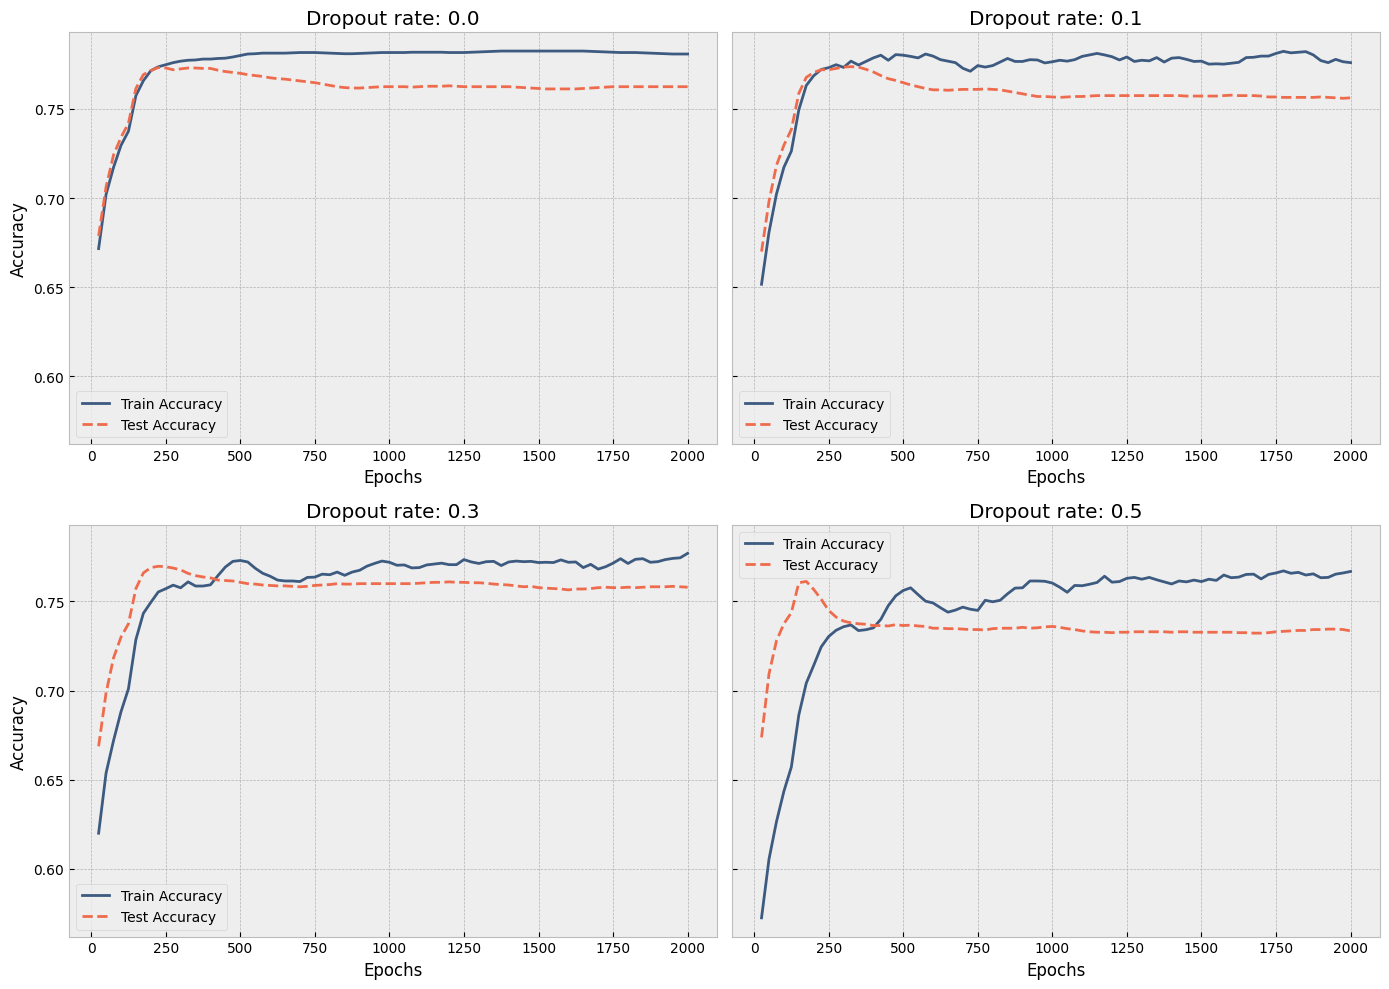

In [73]:
plt.style.use('bmh')
colors = ["#3d5a80", "#ee6c4d"]
window_size = 5

fig, axes = plt.subplots(2, 2, figsize=(14, 10), sharey=True)
axes = axes.flatten()  # makes indexing easy: axes[0..3]

for idx, dropout_rate in enumerate(dropout_rates):
    ax = axes[idx]
    hist = histories[dropout_rate]

    smooth_train = pd.Series(hist['train']).rolling(window=window_size, min_periods=1).mean()
    smooth_test  = pd.Series(hist['test']).rolling(window=window_size, min_periods=1).mean()

    ax.plot(hist['ticks'], smooth_train, label='Train Accuracy', color=colors[0], linewidth=2)
    ax.plot(hist['ticks'], smooth_test,  label='Test Accuracy',  color=colors[1], linewidth=2, linestyle='--')

    ax.set_title(f'Dropout rate: {dropout_rate}')
    ax.set_xlabel('Epochs')
    if idx % 2 == 0:          # left column only
        ax.set_ylabel('Accuracy')
    ax.legend()
    ax.grid(True)

plt.tight_layout()
plt.savefig('dropout_training.png')
plt.show()
